# Ensembles of models and feature selection

Let us define some basic imports and a `pprint` function.

In [1]:
import numpy as np
import pandas as pd
import sklearn
import warnings
warnings.filterwarnings('ignore')
from tqdm.auto import tqdm
from IPython.display import display, Math
from numpyarray_to_latex.jupyter import to_ltx
import matplotlib.pyplot as plt
plt.style.use(['seaborn-v0_8-muted', 'practicals.mplstyle'])
import seaborn as sns
def pprint(*args):
    res = ""
    for i in args:
        if type(i) == np.ndarray:
            res += to_ltx(i, brackets='[]')
        elif type(i) == str:
            res += i
    display(Math(res))

## Reminder:  Supervised learning

Supervised learning aims to model the (unknown) stochastic dependence between a set of $n$ inputs $x$ (also called features) and an output ${\mathbf y}$ on the basis of a training set $D_N$ of size $N$. Supervised learning tasks are decomposed into *regression* and *classification* tasks.
### Regression
In regression the stochastic dependence is given by

$$ {\mathbf y} = f(x)+\mathbf{w}$$

where:
- $\mathbf{y} \in \mathbb{R}$ represents the output variable (also called target)
- $x \in \mathbb{R}^n$ represents the vector of inputs (also called features)
- $\mathbf{w}$ denotes the noise, and is typically assumed that $E[\mathbf{w}]=0$ and the variance 
 $\text{Var}[\mathbf{w}]=\sigma^2_{\mathbf{w}}$ is constant
- $f(x)=E[{\mathbf y} | x]$ is the (unknown) mapping between input and outputs, also known as the *regression function*.

In regression, the goal of learning is to return an estimator 

$$h(x,\alpha)$$

of the regression function $f(x)$, where $\alpha$ denotes the set of parameters of the model $h$.

### Error measurement
We already have used the _mean squared error_ as an evaluation tool for the quality of the predictions of a model. Unfortunately, this tool does not take into account how "variable" the expected outputs are, and therefore two models could become undistinguishable when using the MSE. We can normalize the MSE by dividing it by the (measured) variance of the output data. This leads to the _normalized mean squared error_:

$$\text{NMSE} = \frac{\sum(y-\hat{y})^2}{N\sigma^2_y}$$

We can see that the most naive model which outputs the mean of the observed outputs should give:

$$\frac{\sum(y-\mu_y)^2}{N\sigma^2_y} = \frac{\sigma^2_y}{\sigma^2_y} = 1$$

Any model that has a NMSE greater than $1$ is therefore performing worse than the most naive model. 

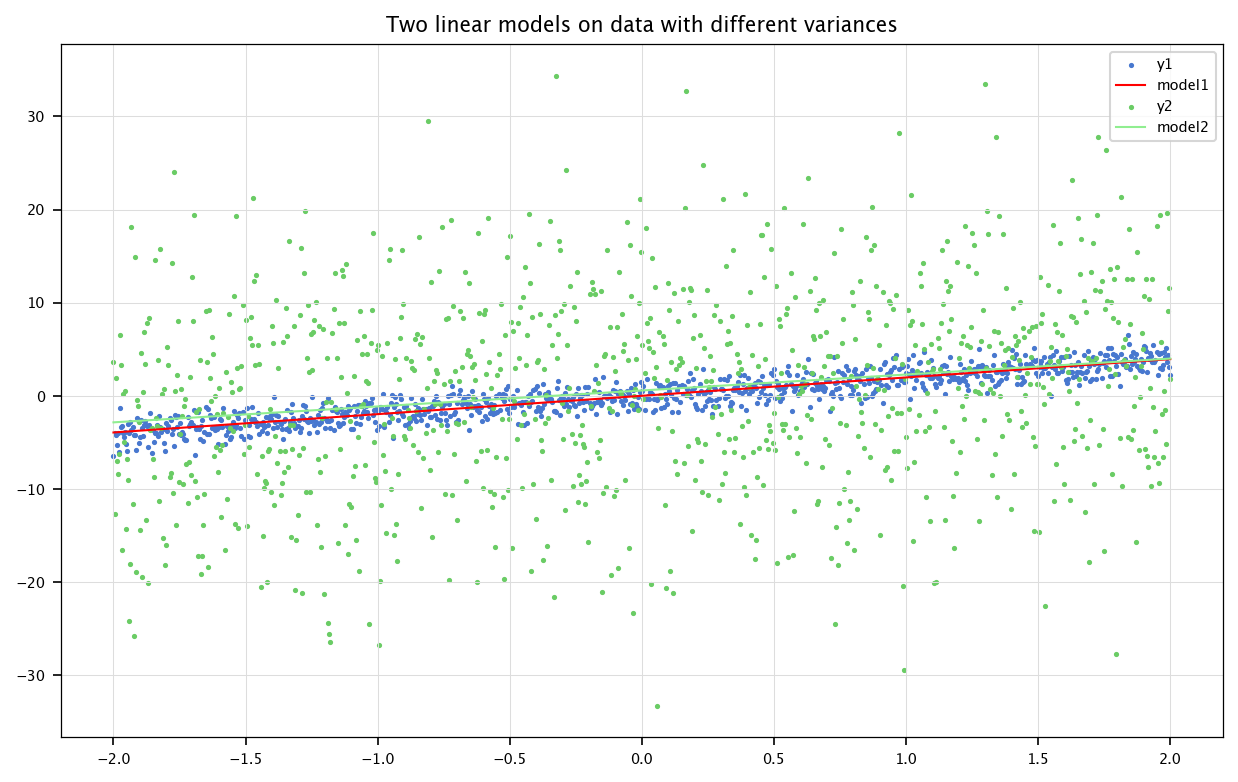

In [2]:
from sklearn.linear_model import LinearRegression
x = np.linspace(-2, 2, 1000).reshape(1000,-1)
B1, B2 = np.random.normal(0, 1, size=(1000,1)), np.random.normal(0, 10, size=(1000,1))
A = 2
y1 = A*x+B1
y2 = A*x+B2

model1 = LinearRegression().fit(x, y1)
model2 = LinearRegression().fit(x, y2)

plt.figure(figsize=(10, 6))
plt.scatter(x, y1, marker='.', label='y1')
plt.plot(x, model1.predict(x), color='red', label='model1')
plt.scatter(x, y2, marker='.', label='y2')
plt.plot(x, model2.predict(x), color='lightgreen', label='model2')
plt.title("Two linear models on data with different variances")
plt.legend()
plt.grid("on")
plt.show()

In [3]:
def mse(y, y_hat):
    return np.mean((y-y_hat)**2)

def nmse(y, y_hat):
    return np.mean((y-y_hat)**2)/np.std(y)**2

In [4]:
print(f"MSEs: {mse(y1, model1.predict(x))}, {mse(y2, model2.predict(x))}")
print(f"NMSEs: {nmse(y1, model1.predict(x))}, {nmse(y2, model2.predict(x))}")

MSEs: 1.051874601439384, 102.696829717452
NMSEs: 0.16885724586364886, 0.963320410110144


## Feature selection
Feature selection and ensembles of models are two techniques which can be used to improve the accuracy of predictions.

Feature selection aims at reducing the dimensionality of the problem, and is useful when input variables contain redundant or irrelevant (noisy) information. Benefits are twofold: it decreases the training time by simplifying the problem, and it decreases the complexity of the predictive model. This in turn usually improves the prediction accuracy, since high-dimensionality makes predictive models more prone to overfitting, and estimates of parameters more variant.

There are three main approaches to feature selection:
- **Filter methods:** 
These methods rely solely on the data and their intrinsic properties, without considering the impact of the selected features on the learning algorithm performance. For this reason, they are often used as preprocessing techniques.

- **Wrapper methods:** 
These methods assess subsets of variables according to their usefulness to a given predictor. The feature selection is performed using an evaluation function that includes the predictive performance of the considered learning algorithm as a selection criterion.

- **Embedded methods:** 
These methods are specific to given learning machines, and usually built-in in the learning procedure (e.g. random forest, regularization based techniques).

Ensembles of models consist in building several predictive models using resampled subsets of the original training set. The method works particularly well for predictive models with high variance (for example, decision trees or neural networks). The average prediction of the resulting models usually strongly decreases the variance component of the error, and as a consequence improves the prediction accuracy.

In this session, we will use a synthetic dataset, made of 30 continuous variables. 24 of them will be useless, and 6 will serve in the output. The output will be a function of the useful input variables.

### Data overview and preprocessing

In [5]:
def compute(data):
    data['y'] = np.zeros(data.shape[0])
    for i in range(6):
        if i%3 == 0:
            data['y'] += np.random.uniform(-1, 1) * data[f'x_useful_{i+1}'] + np.random.uniform(-5, 5)
        elif i%3 == 1:
            data['y'] += np.random.uniform(-1, 1) * data[f'x_useful_{i+1}']**2 + np.random.uniform(-5, 5)
        elif i%3 == 2:
            data['y'] += np.random.uniform(-1, 1) * np.sin(data[f'x_useful_{i+1}']) + np.random.uniform(-5, 5)
    return data

In [6]:
n_x_useful = 6
n_x_useless = 24
n_samples = 1000
d = {}
np.random.seed(0)

for i in range(n_x_useful):
    m, s = np.random.uniform(-1, 1), np.random.uniform(0.5, 2.5)
    d[f'x_useful_{i+1}'] = np.random.normal(m, s, size=(n_samples,))
for i in range(n_x_useless):
    m, s = np.random.uniform(-1, 1), np.random.uniform(0.5, 2.5)
    d[f'x_useless_{i+1}'] = np.random.normal(m, s, size=(n_samples,))

data = pd.DataFrame(d)

data = compute(data)

In [7]:
data.describe(include='all')

,x_useful_1,x_useful_2,x_useful_3,x_useful_4,x_useful_5,x_useful_6,x_useless_1,x_useless_2,x_useless_3,x_useless_4,...,x_useless_16,x_useless_17,x_useless_18,x_useless_19,x_useless_20,x_useless_21,x_useless_22,x_useless_23,x_useless_24,y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.008883,0.787868,-0.862362,-0.220739,0.900991,0.048531,0.848947,0.019645,0.655122,-0.189598,...,-0.421467,0.821257,-0.011411,0.441756,-0.958489,-0.384471,-0.152625,-0.518022,0.051116,-7.379040
std,1.904117,2.362233,1.466222,0.881817,1.535395,0.512844,1.362313,1.729953,1.665836,0.771923,...,0.922338,0.862039,2.287231,1.402679,1.452495,0.787796,0.610938,2.501076,1.985946,1.890504
min,-5.782583,-6.520188,-5.587836,-3.444757,-3.751236,-1.380297,-3.305645,-5.469208,-4.426479,-2.355184,...,-3.443265,-1.763982,-7.985982,-4.070035,-5.422766,-2.947481,-1.917751,-11.958636,-6.453296,-13.989287
25%,-1.250588,-0.839990,-1.910921,-0.821390,-0.111143,-0.293415,-0.091018,-1.090598,-0.432532,-0.738497,...,-1.025653,0.250196,-1.464619,-0.527079,-1.967275,-0.890462,-0.564771,-2.155428,-1.329528,-8.514752
50%,-0.014389,0.822298,-0.868373,-0.229933,0.883910,0.050555,0.825699,0.014043,0.655699,-0.199494,...,-0.423784,0.844540,0.021261,0.423711,-1.010335,-0.403122,-0.147460,-0.412912,0.054168,-7.414389
75%,1.269272,2.284124,0.175776,0.372973,1.957939,0.386908,1.786537,1.128925,1.744190,0.350852,...,0.211144,1.361641,1.522601,1.368873,0.002406,0.173736,0.252462,1.202683,1.373122,-6.287151
max,5.424227,8.481613,3.712036,3.085683,5.435128,1.539755,4.825280,5.912388,5.919659,2.026439,...,3.010346,4.035696,7.689106,5.682900,3.504355,2.146540,1.745356,8.160750,5.685927,2.202998


### Input and output variables

The output variable (Y) is `y`, and all other variables (X) are considered as inputs.

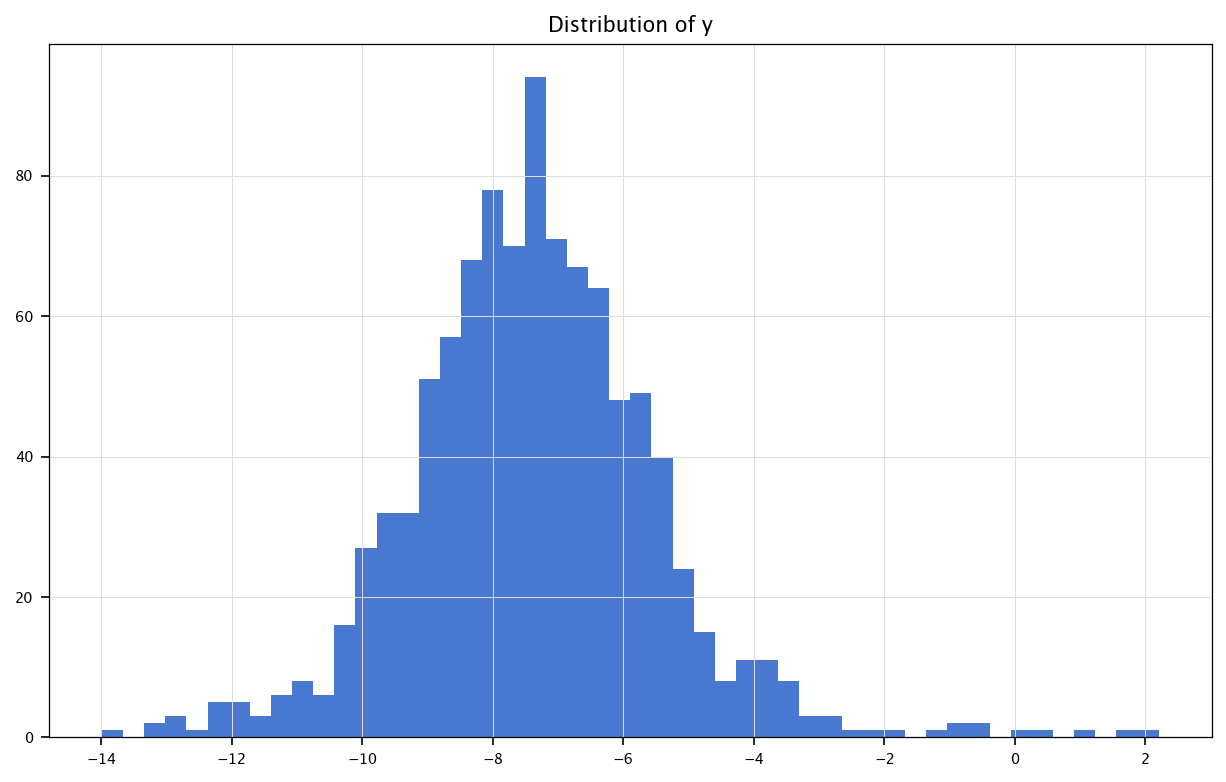

Mean of Y: -7.379040070934719
Variance of Y: 3.5704323990926374


In [8]:
Y = data['y'].values
X = data.drop(columns=['y'])

N = X.shape[0]
n = X.shape[1]

plt.figure(figsize=(10, 6))
plt.hist(Y, bins=50)
plt.title("Distribution of y")
plt.grid("on")
plt.show()

print("Mean of Y:", np.mean(Y))
print("Variance of Y:", np.var(Y))

### Modelling with linear and decision tree models

#### Linear model

* Create a linear model $h(x)$ for predicting the IMDB score on the basis of the input variables, and compute its empirical (or training) mean square error.

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, Y)
Y_hat = model.predict(X)

empirical_error = nmse(Y, Y_hat)
print(f"Empirical error: {empirical_error:.5f}")

Empirical error: 0.55375


* Which input variables are statistically correlated with the output?

In Python, we can check the coefficients of the linear model.

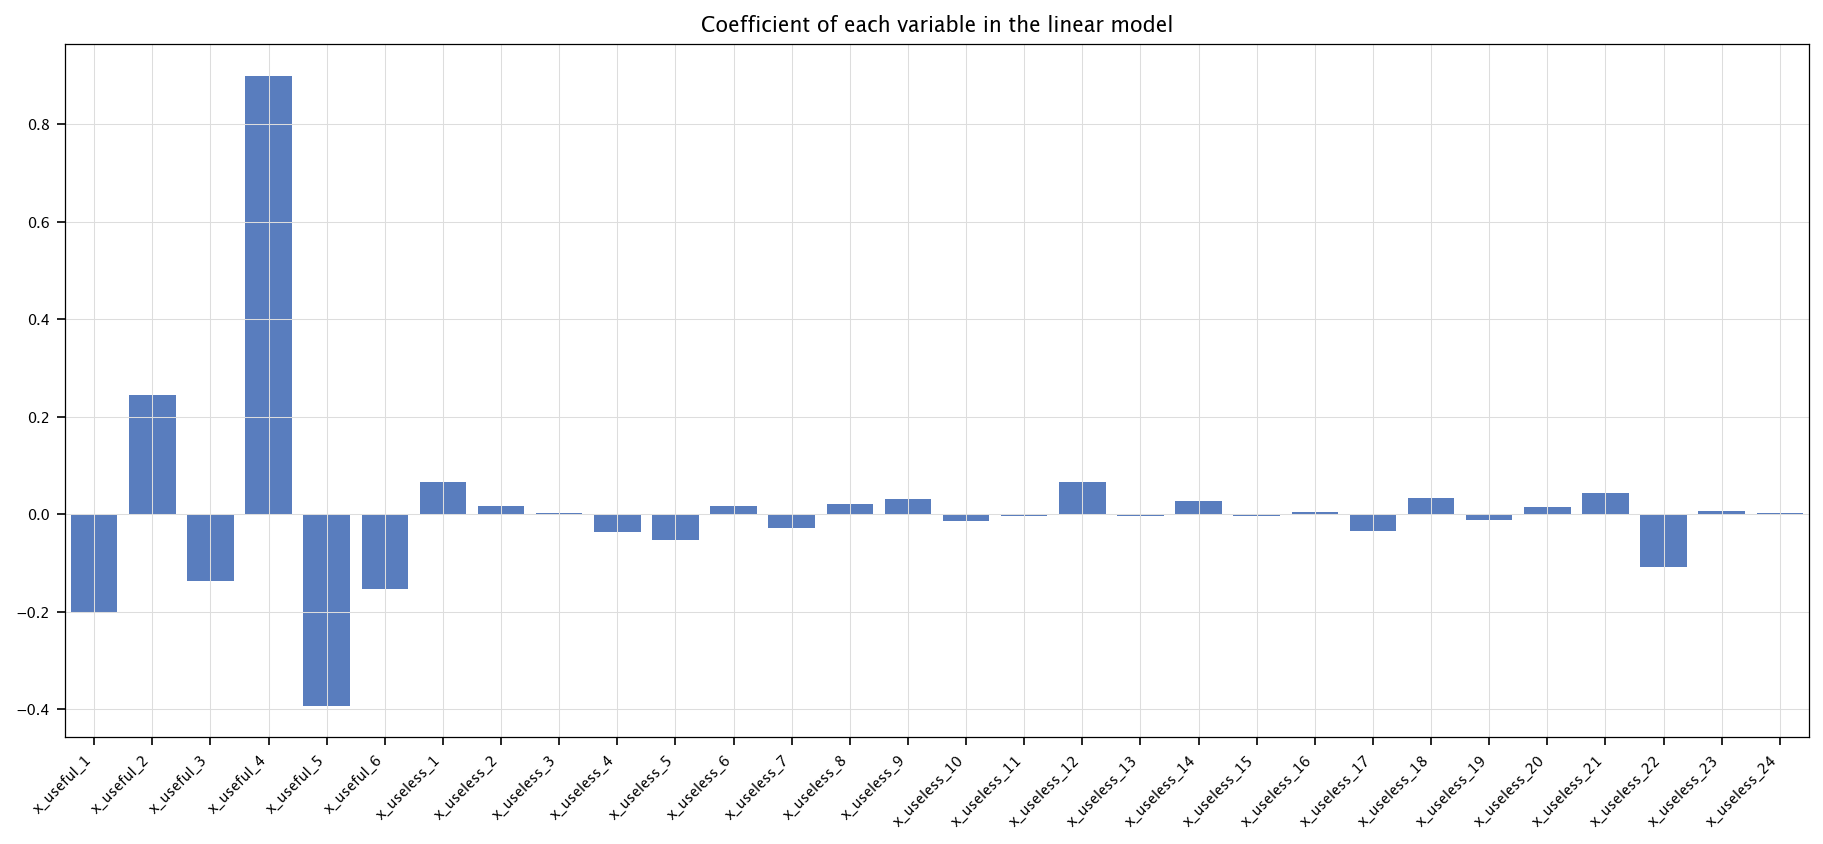

In [10]:
coefs = pd.Series(model.coef_, index=X.columns)
plt.figure(figsize=(15, 6))
sns.barplot(coefs)
plt.title("Coefficient of each variable in the linear model")
plt.xticks(rotation=45, ha='right')
plt.grid("on")
plt.show()

* Compute the validation error with a 10-fold cross-validation

In [11]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=3)
CV_err_lm_single_model = []

for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    model = LinearRegression()
    model.fit(X_tr, Y_tr)
    Y_hat_ts = model.predict(X_ts)
    CV_err_lm_single_model.append(nmse(Y_ts, Y_hat_ts))

print(f"CV error: {np.mean(CV_err_lm_single_model):.5f}, std dev: {np.std(CV_err_lm_single_model):.5f}")

CV error: 0.61060, std dev: 0.08403


#### Decision tree

* Modify the previous code to compute the empirical error using a decision tree model. Use sklearn's `DecisionTreeRegressor`.

In [12]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=3)
model.fit(X, Y)
Y_hat = model.predict(X)

empirical_error = nmse(Y, Y_hat)
print(f"Empirical error: {empirical_error:.5f}")

Empirical error: 0.00000


* Plot the resulting tree is more complicated in Python due to size, but we can just visualize its structure or get the depth.

In [13]:
print(f"Depth: {model.get_depth()}, number of leaves: {model.get_n_leaves()}")

Depth: 22, number of leaves: 1000


* What is the 10-fold cross-validation error using a decision tree model?

In [14]:
CV_err_rpart_single_model = []

for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    model = DecisionTreeRegressor(random_state=3)
    model.fit(X_tr, Y_tr)
    Y_hat_ts = model.predict(X_ts)
    CV_err_rpart_single_model.append(nmse(Y_ts, Y_hat_ts))

print(f"CV error: {np.mean(CV_err_rpart_single_model):.5f}, std dev: {np.std(CV_err_rpart_single_model):.5f}")

CV error: 0.33924, std dev: 0.08885


Why is the result so different using the 10-fold cross-validation?

#### Ridge regression with LOO-CV
Recall: Ridge regression looks like a linear regression but includes a penalty term for large coefficients:

$$
  \min_{\beta} \;\; \| Y - X \beta \|^2 + \lambda \| \beta \|^2.
$$


Ridge also has a known closed-form:

$$
  \hat{\beta}_{\mathrm{ridge}} = (X^\top X + \lambda I)^{-1} X^\top Y.
$$

* Leave-one out cross-validation is a method that consists in evaluating a given model by training it on the entire training set, except for one sample used for validation. By performing this validation, eliminating each of the samples at a time, we get an estimation of the quality of the model.
* Then, the coefficients can give an idea of the importance of each of the features in the prediction task.

Here, we limit the dataset size to $50$ items, to avoid too long computations.

  0%|          | 0/50 [00:00<?, ?it/s]

Best lambda: 0.2822222222222222
Greatests coefficients indexes: [ 0  4 27 23]
Greatests coefficients: [-7.1367055   0.89720319 -0.34672033 -0.33732339]


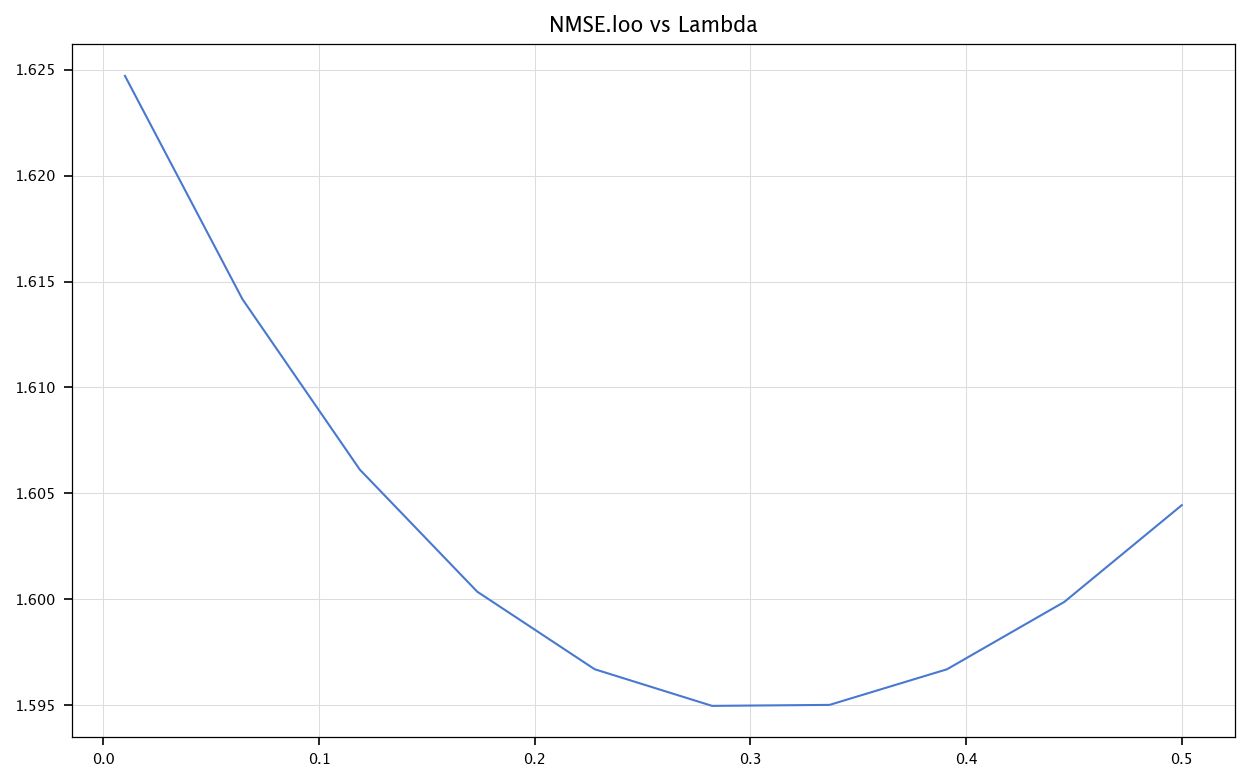

In [15]:
X_np = X.to_numpy()[:50]

N = X_np.shape[0]
lambdas = np.linspace(0.01, 0.5, 10)
E = np.empty((N, len(lambdas)))  
E[:] = np.nan

for i in tqdm(range(N)):
    Xtr = np.column_stack((np.ones(N - 1), np.delete(X_np, i, axis=0)))
    Ytr = np.delete(Y[:50], i)
    
    Xts = np.concatenate(([1], X_np[i,]))
    
    cnt = 0
    for l in lambdas:
        A = Xtr.T @ Xtr + l * np.eye(n + 1)
        b = Xtr.T @ Ytr
        betahat = np.linalg.inv(A) @ b
        Yhati = Xts @ betahat
        E[i, cnt] = ((Y[i] - Yhati) ** 2)
        cnt += 1

mseloo = np.mean(E, axis=0)/np.std(Y)**2

bestLambda = lambdas[np.argmin(np.mean(E, axis=0))]
print(f"Best lambda: {bestLambda}")

XX = np.column_stack((np.ones(N), X_np))
A_final = np.dot(XX.T, XX) + bestLambda * np.eye(n + 1)
b_final = np.dot(XX.T, Y[:50])
betahat = np.linalg.inv(A_final) @ XX.T @ Y[:50]

abs_betahat = np.abs(betahat)
sorted_indices = np.argsort(-abs_betahat)
top4 = sorted_indices[:4] 
print(f"Greatests coefficients indexes: {top4}")
print(f"Greatests coefficients: {betahat[top4]}")
plt.figure(figsize=(10, 6))
plt.plot(lambdas, mseloo)
plt.title('NMSE.loo vs Lambda')
plt.grid("on")
plt.show()

#### Selection bias
Take care that if the features are selected using the error on the training set as an importance criterium leads to a flaw: the features may be over-fittingly selected and the performances then do not reflect on the testing performances dataset.

  0%|          | 0/15 [00:00<?, ?it/s]

<IPython.core.display.Math object>

<IPython.core.display.Math object>

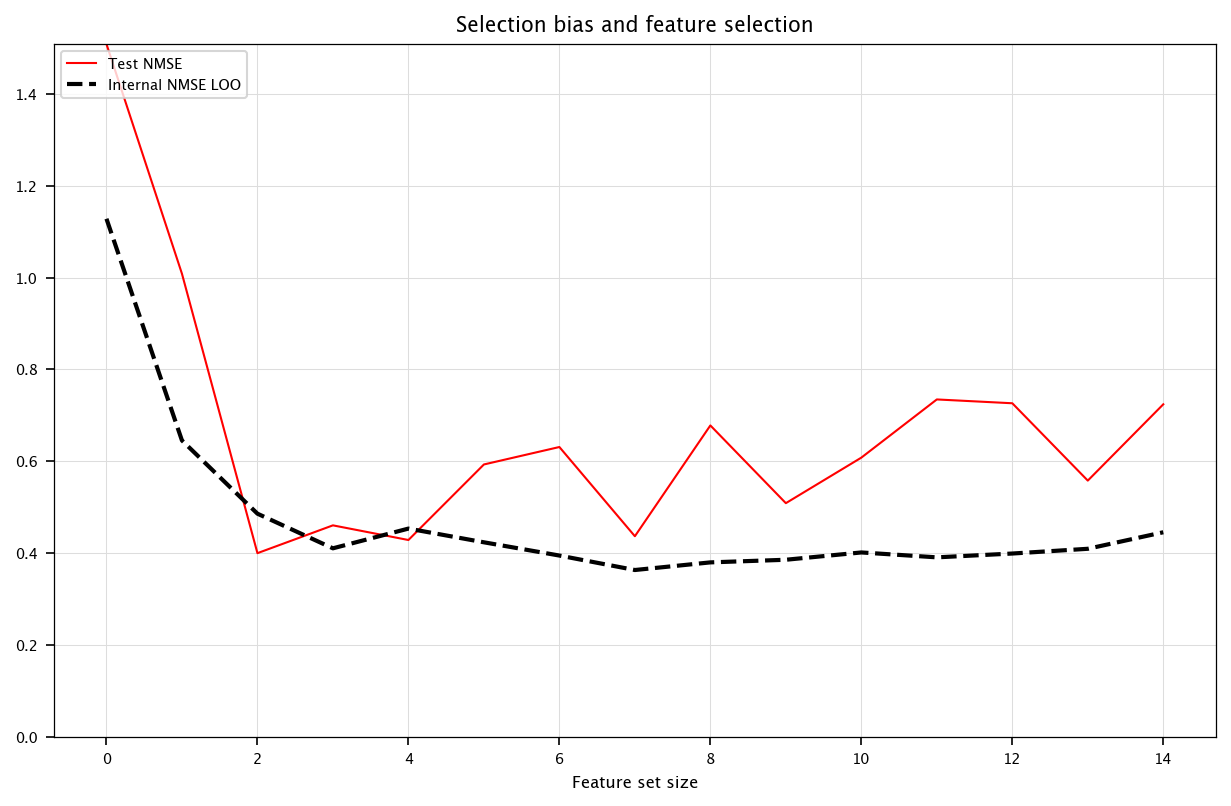

In [16]:
def pred(X_train, Y_train, X_test):
   reg = sklearn.tree.DecisionTreeRegressor().fit(X_train, Y_train)
   return reg.predict(X_test)

X_tr = X.to_numpy()[:200]
Y_tr = Y[:200]
X_ts = X.to_numpy()[200:250]
Y_ts = Y[200:250]

N_tr = X_tr.shape[0]

fset = []
bestr = []
bests = []

for it in tqdm(range(15)):
    NMSEf = {}
    candidates = [f for f in range(n) if f not in fset]
    for f in candidates:
        e = np.empty(N_tr)
        for i in range(N_tr):
            X_train_all = np.delete(X_tr, i, axis=0)
            Y_train_all = np.delete(Y_tr, i) 
            cols = [j - 1 for j in (fset + [f])]
            X_train = X_train_all[:, cols]
            X_test_sample = X_tr[i, cols]
            Yhati = pred(X_train, Y_train_all, X_test_sample.reshape(1, -1))
            e[i] = (Y[i] - Yhati)**2/np.std(Y_tr)**2
        NMSEf[f] = np.mean(e)
    f_best = min(NMSEf, key=NMSEf.get)
    fset.append(f_best)
    bestr.append(NMSEf[f_best])
    cols = [j - 1 for j in fset]
    Y_hats = pred(X_tr[:, cols], Y_tr, X_ts[:, cols])
    nmse_test = nmse(Y_hats, Y_ts)
    bests.append(nmse_test) 
    
pprint(fset)
pprint(np.array(bests) - np.array(bestr))

plt.figure(figsize=(10, 6))
plt.plot(bests, color="red", label="Test NMSE")
plt.plot(bestr, linestyle="--", linewidth=2, color="black", label="Internal NMSE LOO")
plt.ylim(0, max(bests))
plt.title("Selection bias and feature selection")
plt.xlabel("Feature set size")
plt.ylabel("")
plt.legend(loc="upper left")
plt.grid("on")
plt.show()

### Ensemble of models

Let us now create an ensemble of R=20 linear models to make predictions.
* Use a linear model as the base model.

In [17]:
R = 20
CV_err_lm_ensemble_model = []

for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    Y_hat_ts_ensemble = np.zeros((X_ts.shape[0], R))
    for r in range(R):
        idx_tr_resample = np.random.choice(train_index, size=len(train_index), replace=True)
        X_tr_res = X.iloc[idx_tr_resample]
        Y_tr_res = Y[idx_tr_resample]
        
        model = LinearRegression()
        model.fit(X_tr_res, Y_tr_res)
        Y_hat_ts_ensemble[:, r] = model.predict(X_ts)
    
    Y_hat_ts = np.mean(Y_hat_ts_ensemble, axis=1)
    CV_err_lm_ensemble_model.append(nmse(Y_ts, Y_hat_ts))

print(f"CV error: {np.mean(CV_err_lm_ensemble_model):.5f}, std dev: {np.std(CV_err_lm_ensemble_model):.5f}")
print("Is ensemble error lower than single model?", np.mean(CV_err_lm_ensemble_model) < np.mean(CV_err_lm_single_model))

CV error: 0.60855, std dev: 0.08307
Is ensemble error lower than single model? True


* Use a decision tree as the base model. Is the CV error lower?

In [18]:
R = 20
CV_err_rpart_ensemble_model = []

for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    Y_hat_ts_ensemble = np.zeros((X_ts.shape[0], R))
    for r in range(R):
        idx_tr_resample = np.random.choice(train_index, size=len(train_index), replace=True)
        X_tr_res = X.iloc[idx_tr_resample]
        Y_tr_res = Y[idx_tr_resample]
        
        model = DecisionTreeRegressor(random_state=r)
        model.fit(X_tr_res, Y_tr_res)
        Y_hat_ts_ensemble[:, r] = model.predict(X_ts)
    
    Y_hat_ts = np.mean(Y_hat_ts_ensemble, axis=1)
    CV_err_rpart_ensemble_model.append(nmse(Y_ts, Y_hat_ts))

print(f"CV error: {np.mean(CV_err_rpart_ensemble_model):.5f}, std dev: {np.std(CV_err_rpart_ensemble_model):.5f}")
print("Is ensemble error lower than single model?", np.mean(CV_err_rpart_ensemble_model) < np.mean(CV_err_rpart_single_model))

CV error: 0.15982, std dev: 0.04733
Is ensemble error lower than single model? True


## Feature selection

### Filter methods

#### Correlation with the output

The following code performs feature selection by keeping the most correlated variables with the output. Compare the results for linear models and decision trees. What are the smallest CV errors, and how many features were needed?

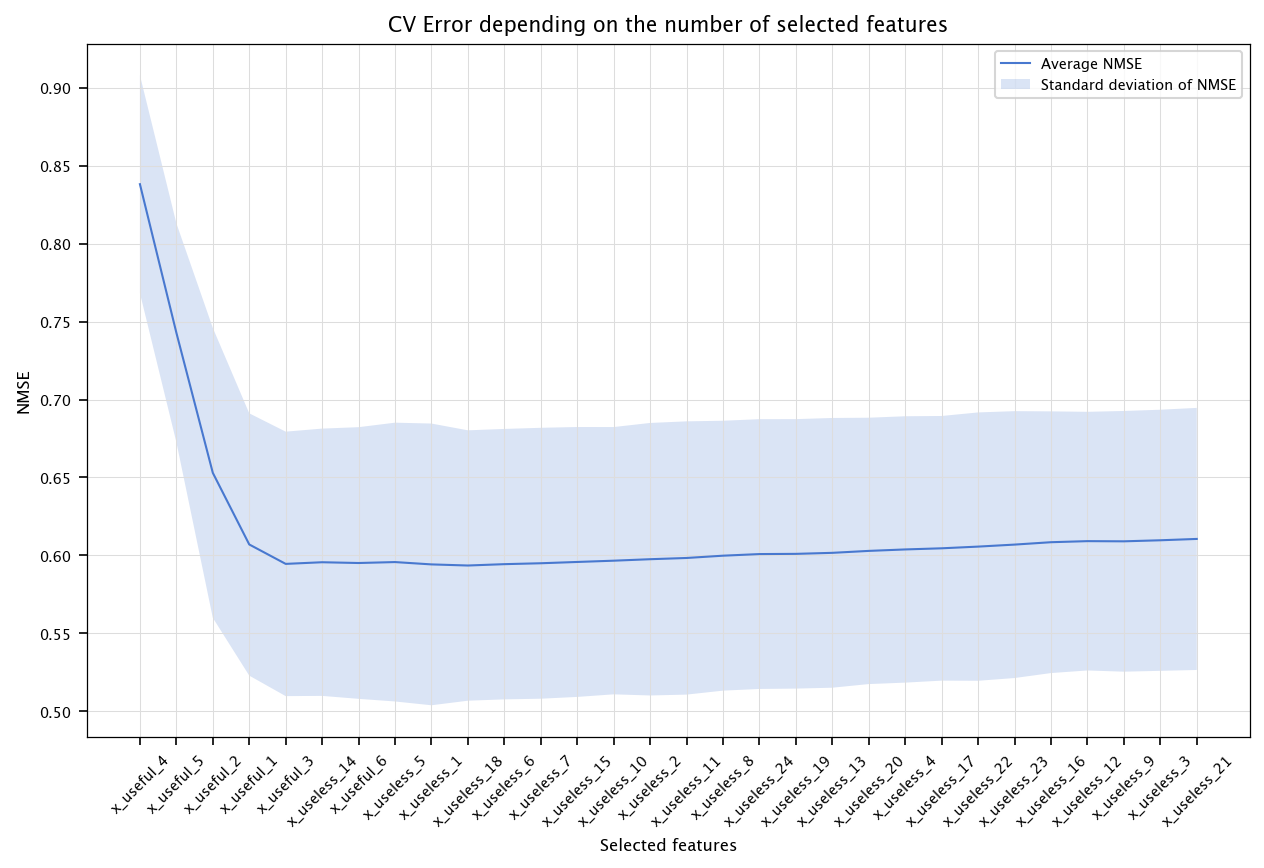

In [19]:
correlations = np.abs(X.corrwith(pd.Series(Y)))
ranking_corr_idx = correlations.sort_values(ascending=False).index

CV_err = np.zeros((n,10))

fold_id = 0
for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    for nb_features in range(1, n+1):
        selected_features = ranking_corr_idx[:nb_features]
        model = LinearRegression()
        model.fit(X_tr[selected_features], Y_tr)
        Y_hat_ts = model.predict(X_ts[selected_features])
        CV_err[nb_features-1, fold_id] = nmse(Y_ts, Y_hat_ts)
    fold_id += 1

x = list(range(1, n+1))
errors = np.array([np.mean(CV_err[i, :]) for i in range(n)])
stds = np.array([np.std(CV_err[i, :]) for i in range(n)])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, errors, label="Average NMSE")
ax.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Standard deviation of NMSE")
ax.set_title("CV Error depending on the number of selected features")
ax.set_xlabel("Selected features")
ax.set_ylabel("NMSE")
ax.set_xticks(ticks=x, labels=ranking_corr_idx.tolist(), rotation=45)
plt.legend()
plt.grid("on")
plt.show()

#### mRMR

We will implement a simple mRMR feature selection. mRMR uses mutual information. We will approximate mutual information via the correlation-based formula provided.

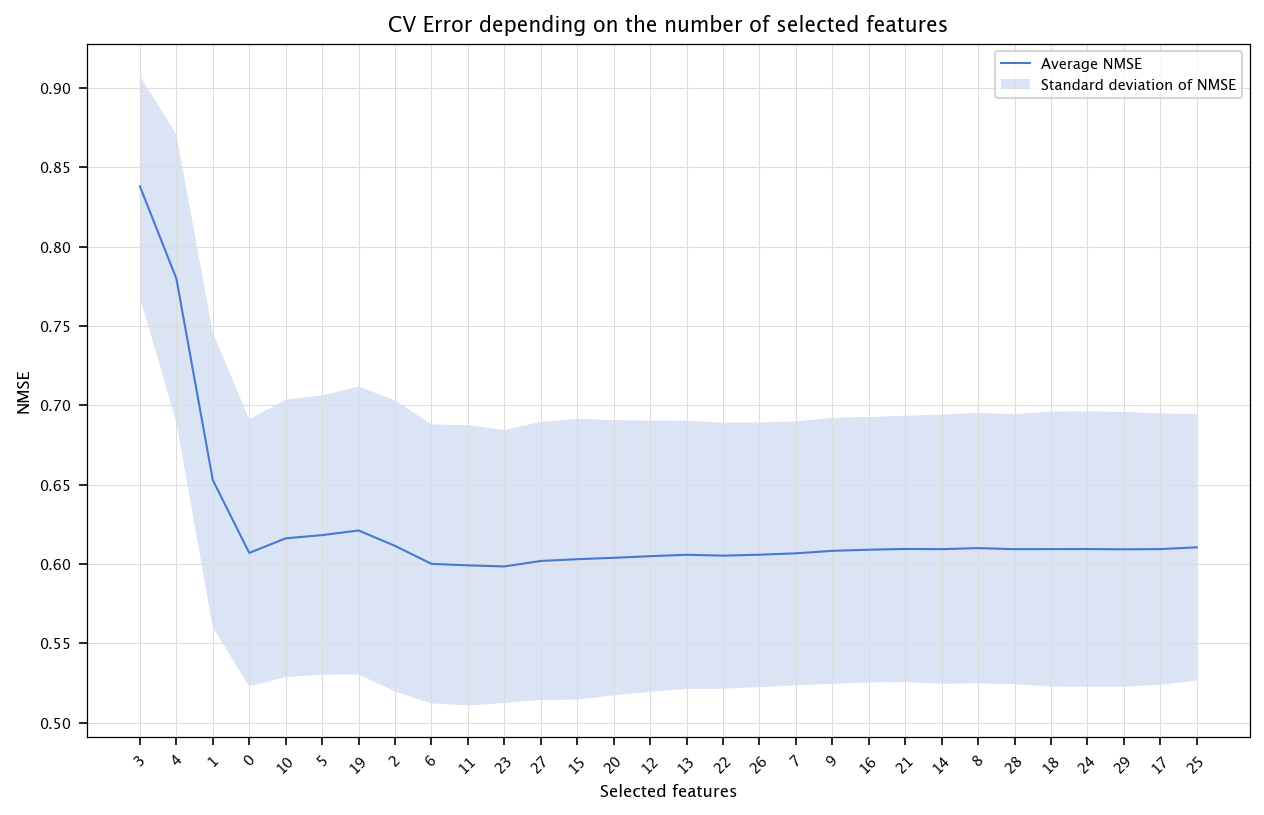

In [20]:
def mutual_info_corr(X, Y):
    c = np.corrcoef(X, Y)[0,1]
    # Avoid invalid value if correlation == 1 or == -1
    if abs(c)==1:
        c = 0.999999
    return -0.5 * np.log(1 - c**2)

def compute_mi_vector(X_tr, Y_tr):
    mis = []
    for col in X_tr.columns:
        mi = mutual_info_corr(X_tr[col].values, Y_tr)
        mis.append(mi)
    return np.array(mis)

CV_err = np.zeros((n,10))

fold_id = 0
for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    mutual_info_values = compute_mi_vector(X_tr, Y_tr)
    selected = []
    candidates = list(range(n))
    
    for j in range(n):
        redundancy_score = np.zeros(len(candidates))
        if len(selected)>0:
            # Compute pairwise mi between selected and candidates
            mi_sc = []
            for cidx in candidates:
                col_c = X_tr.iloc[:, cidx]
                mis_c = []
                for sidx in selected:
                    col_s = X_tr.iloc[:, sidx]
                    # Compute mutual info between col_s and col_c
                    cc = np.corrcoef(col_s, col_c)[0,1]
                    if abs(cc)==1:
                        cc=0.999999
                    mis_c.append(-0.5*np.log(1-cc**2))
                redundancy_score[candidates.index(cidx)] = np.mean(mis_c)
        mRMR_score = mutual_info_values[candidates] - redundancy_score
        best_idx = candidates[np.argmax(mRMR_score)]
        selected.append(best_idx)
        candidates.remove(best_idx)
    
    # selected is the ranking
    for nb_features in range(1, n+1):
        features_to_use = [X.columns[i] for i in selected[:nb_features]]
        model = LinearRegression()
        model.fit(X_tr[features_to_use], Y_tr)
        Y_hat_ts = model.predict(X_ts[features_to_use])
        CV_err[nb_features-1, fold_id] = nmse(Y_ts, Y_hat_ts)
    fold_id += 1

x = list(range(1, n+1))
errors = np.array([np.mean(CV_err[i, :]) for i in range(n)])
stds = np.array([np.std(CV_err[i, :]) for i in range(n)])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, errors, label="Average NMSE")
ax.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Standard deviation of NMSE")
ax.set_title("CV Error depending on the number of selected features")
ax.set_xlabel("Selected features")
ax.set_ylabel("NMSE")
ax.set_xticks(ticks=x, labels=selected, rotation=45)
plt.legend()
plt.grid("on")
plt.show()

#### PCA

The following code performs features selection by first transforming the inputs using PCA, and then keeping the most relevant principal components in the model.

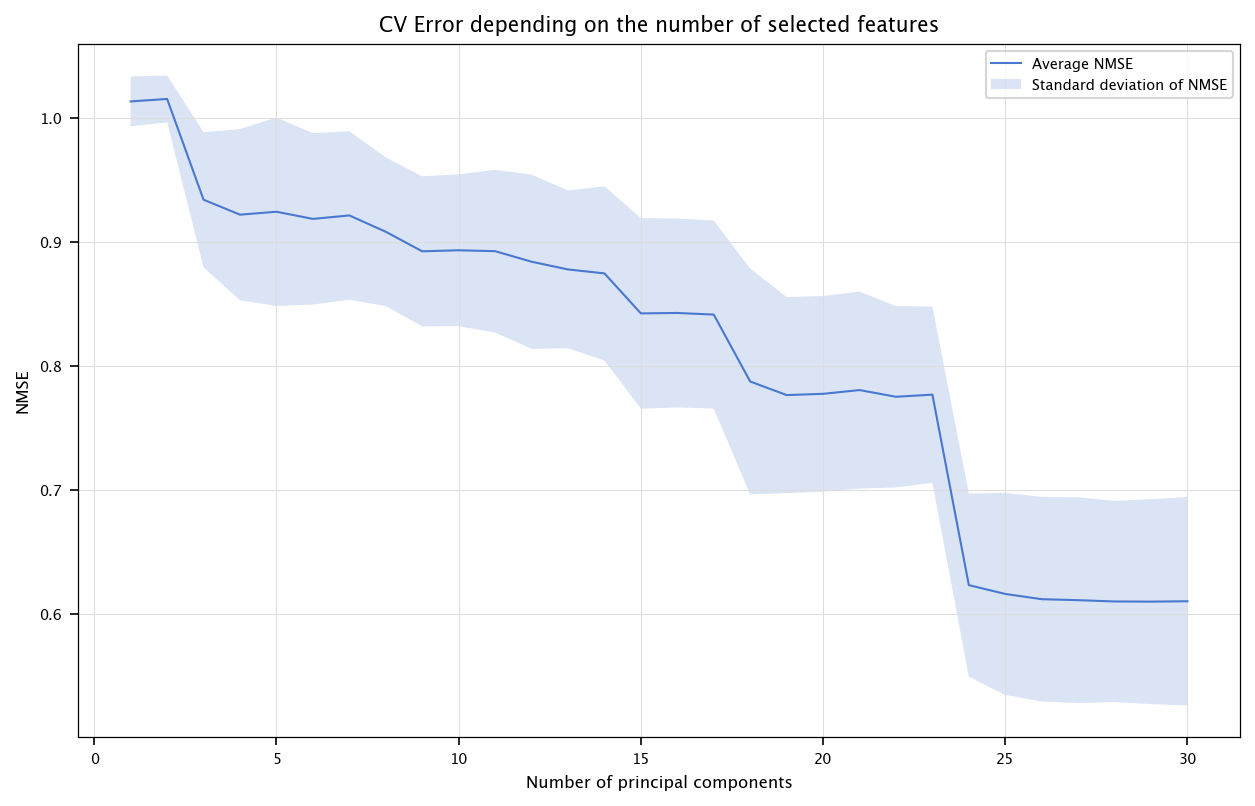

In [21]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X)

CV_err = np.zeros((n,10))
fold_id = 0
for train_index, test_index in kf.split(X_pca):
    X_tr, X_ts = X_pca[train_index], X_pca[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    for nb_components in range(1, n+1):
        model = LinearRegression()
        model.fit(X_tr[:, :nb_components], Y_tr)
        Y_hat_ts = model.predict(X_ts[:, :nb_components])
        CV_err[nb_components-1, fold_id] = nmse(Y_ts, Y_hat_ts)
    fold_id += 1

x = list(range(1, n+1))
errors = np.array([np.mean(CV_err[i, :]) for i in range(n)])
stds = np.array([np.std(CV_err[i, :]) for i in range(n)])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, errors, label="Average NMSE")
ax.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Standard deviation of NMSE")
ax.set_title("CV Error depending on the number of selected features")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("NMSE")
plt.legend()
plt.grid("on")
plt.show()

### Wrapper methods

  0%|          | 0/30 [00:00<?, ?it/s]

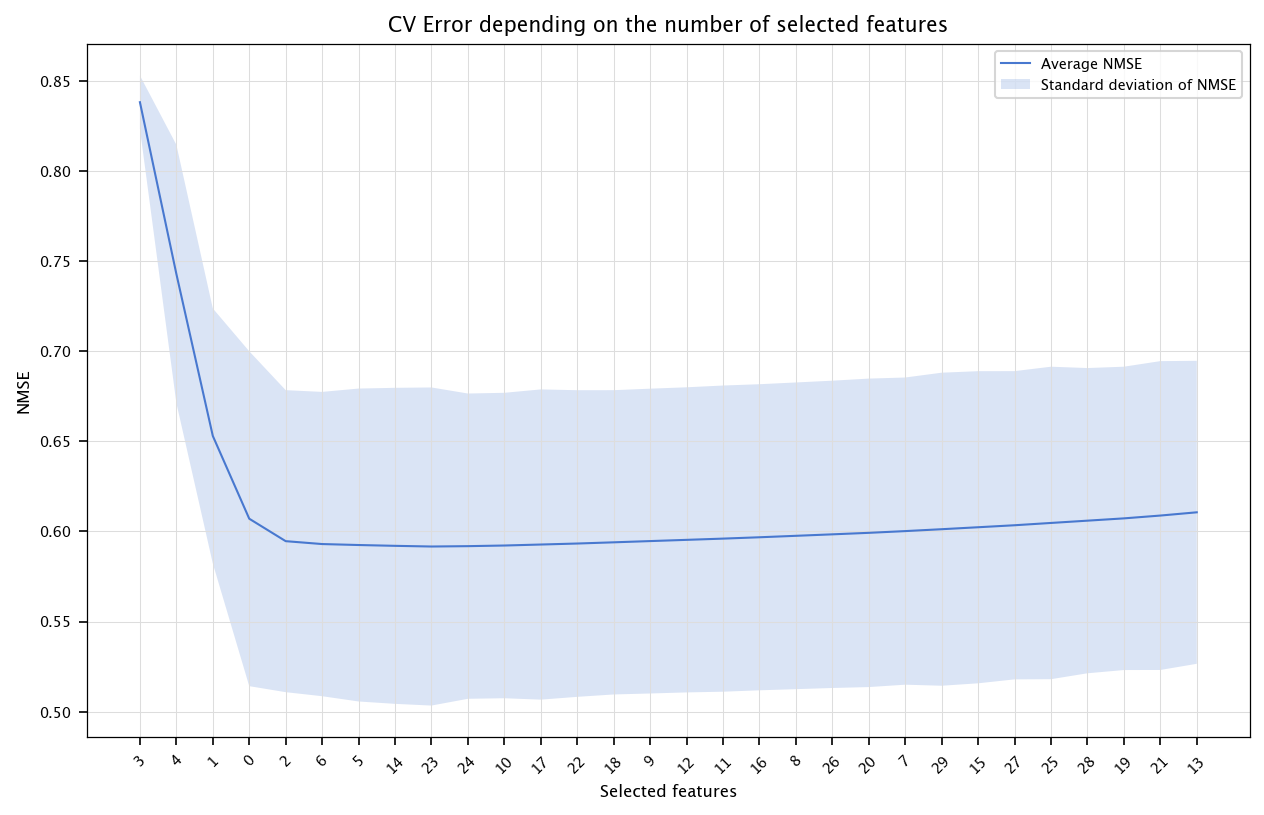

In [22]:
selected = []
CV_errs = []
std_errs = []
for round_i in tqdm(range(n)):
    candidates = list(set(range(n)) - set(selected))
    CV_err_temp = []
    for c in candidates:
        features_to_include = selected + [c]
        fold_errors = []
        for train_index, test_index in kf.split(X):
            X_tr, X_ts = X.iloc[train_index, features_to_include], X.iloc[test_index, features_to_include]
            Y_tr, Y_ts = Y[train_index], Y[test_index]
            
            model = LinearRegression()
            model.fit(X_tr, Y_tr)
            Y_hat_ts = model.predict(X_ts)
            fold_errors.append(nmse(Y_ts, Y_hat_ts))
        CV_err_temp.append(np.mean(fold_errors))
    
    best_candidate = candidates[np.argmin(CV_err_temp)]
    selected.append(best_candidate)
    CV_errs.append(min(CV_err_temp))
    std_errs.append(np.std(fold_errors))

x = list(range(1, n+1))
errors = np.array(CV_errs)
stds = np.array(std_errs)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, errors, label="Average NMSE")
ax.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Standard deviation of NMSE")
ax.set_title("CV Error depending on the number of selected features")
ax.set_xlabel("Selected features")
ax.set_ylabel("NMSE")
ax.set_xticks(ticks=x, labels=selected, rotation=45)
plt.legend()
plt.grid("on")
plt.show()

## Using other predictive models

We can try other models like SVM (SVR), Neural Networks (MLPRegressor), K-Nearest Neighbors (KNeighborsRegressor) and see if performance improves.
* Using SVR, show the error using all the features.

In [23]:
from sklearn.svm import SVR

CV_err_svm_single_model = []
for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    model = SVR()
    model.fit(X_tr, Y_tr)
    Y_hat_ts = model.predict(X_ts)
    CV_err_svm_single_model.append(nmse(Y_ts, Y_hat_ts))

print(f"CV error: {np.mean(CV_err_svm_single_model):.5f}, std dev: {np.std(CV_err_svm_single_model):.5f}")

CV error: 0.30621, std dev: 0.03799


* Then, using cross-validation, use mRMR.

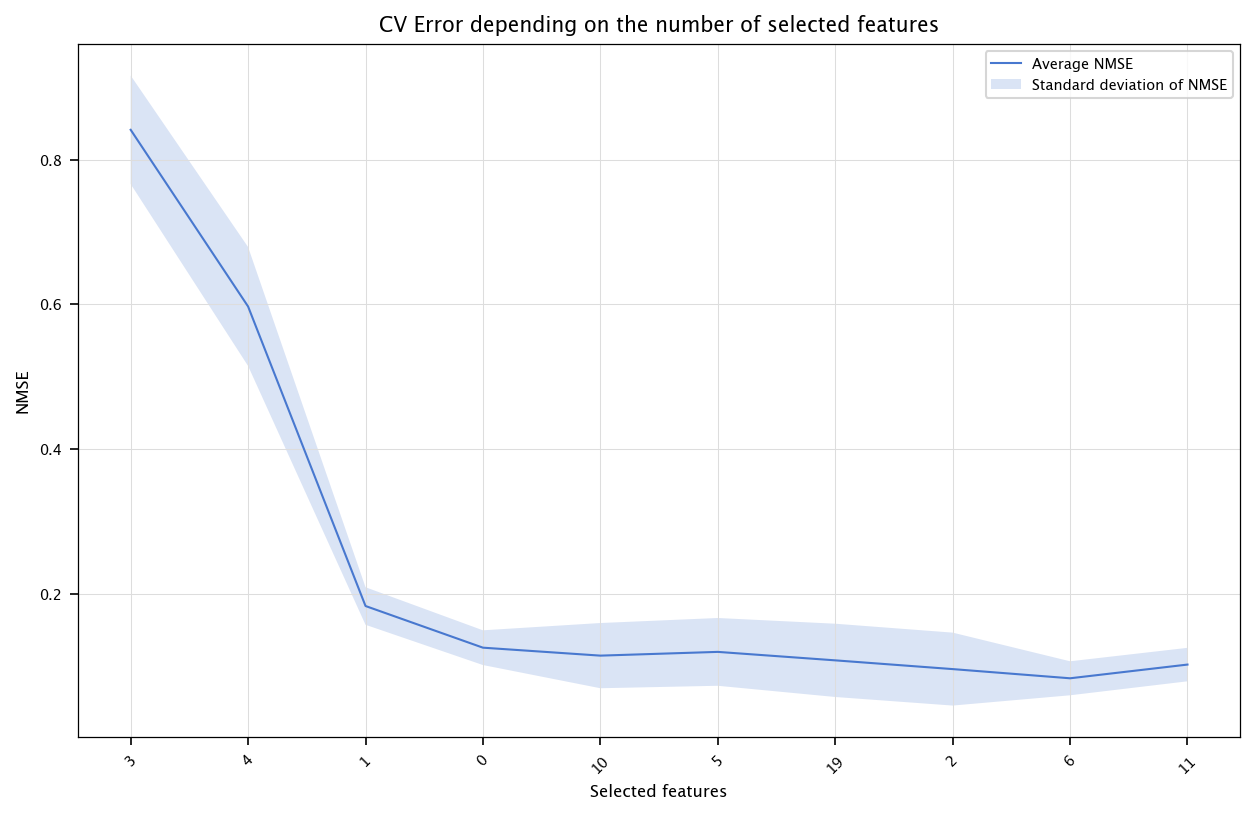

In [24]:
# Feature selection with mRMR for SVM

n_variables = 10

CV_err_svm_single_model_fs = np.zeros((n_variables,10))
fold_id = 0

for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    mutual_info_values = compute_mi_vector(X_tr, Y_tr)
    selected = []
    candidates = list(range(n))
    
    for j in range(n_variables):
        redundancy_score = np.zeros(len(candidates))
        if len(selected)>0:
            for ci, cidx in enumerate(candidates):
                col_c = X_tr.iloc[:, cidx].values
                mis_c = []
                for sidx in selected:
                    col_s = X_tr.iloc[:, sidx].values
                    cc = np.corrcoef(col_s, col_c)[0,1]
                    if abs(cc)==1:
                        cc=0.999999
                    mis_c.append(-0.5*np.log(1-cc**2))
                redundancy_score[ci] = np.mean(mis_c)
        mRMR_score = mutual_info_values[candidates] - redundancy_score
        best_idx = candidates[np.argmax(mRMR_score)]
        selected.append(best_idx)
        candidates.remove(best_idx)
        
    # Evaluate performance with subsets of selected features
    for nb_features in range(1, n_variables+1):
        feats = [X.columns[i] for i in selected[:nb_features]]
        model = SVR()
        model.fit(X_tr[feats], Y_tr)
        Y_hat_ts = model.predict(X_ts[feats])
        CV_err_svm_single_model_fs[nb_features-1, fold_id] = nmse(Y_ts, Y_hat_ts)
    fold_id+=1

x = list(range(1, n_variables+1))
errors = np.array([np.mean(CV_err_svm_single_model_fs[i, :]) for i in range(n_variables)])
stds = np.array([np.std(CV_err_svm_single_model_fs[i, :]) for i in range(n_variables)])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, errors, label="Average NMSE")
ax.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Standard deviation of NMSE")
ax.set_title("CV Error depending on the number of selected features")
ax.set_xlabel("Selected features")
ax.set_ylabel("NMSE")
ax.set_xticks(ticks=x, labels=selected, rotation=45)
plt.legend()
plt.grid("on")
plt.show()

* Do the same for the two other models.

In [25]:
from sklearn.neural_network import MLPRegressor

CV_err_nnet_single_model = []

for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]

    # Rescale input to 0-1
    min_X, max_X = np.min(X_tr), np.max(X_tr)
    X_tr = (X_tr-min_X)/(max_X-min_X)
    X_ts = (X_ts-min_X)/(max_X-min_X)
    
    # Rescale output to 0-1
    min_Y, max_Y = np.min(Y_tr), np.max(Y_tr)
    Y_tr_rescale = (Y_tr-min_Y)/(max_Y-min_Y)
    
    model = MLPRegressor(hidden_layer_sizes=(20,), max_iter=10000, learning_rate_init=0.05, random_state=3)
    model.fit(X_tr, Y_tr_rescale)
    Y_hat_ts = (model.predict(X_ts)*(max_Y-min_Y))+min_Y
    CV_err_nnet_single_model.append(nmse(Y_ts, Y_hat_ts))

print(f"CV error: {np.mean(CV_err_nnet_single_model):.5f}, std dev: {np.std(CV_err_nnet_single_model):.5f}")

CV error: 0.74304, std dev: 0.11244


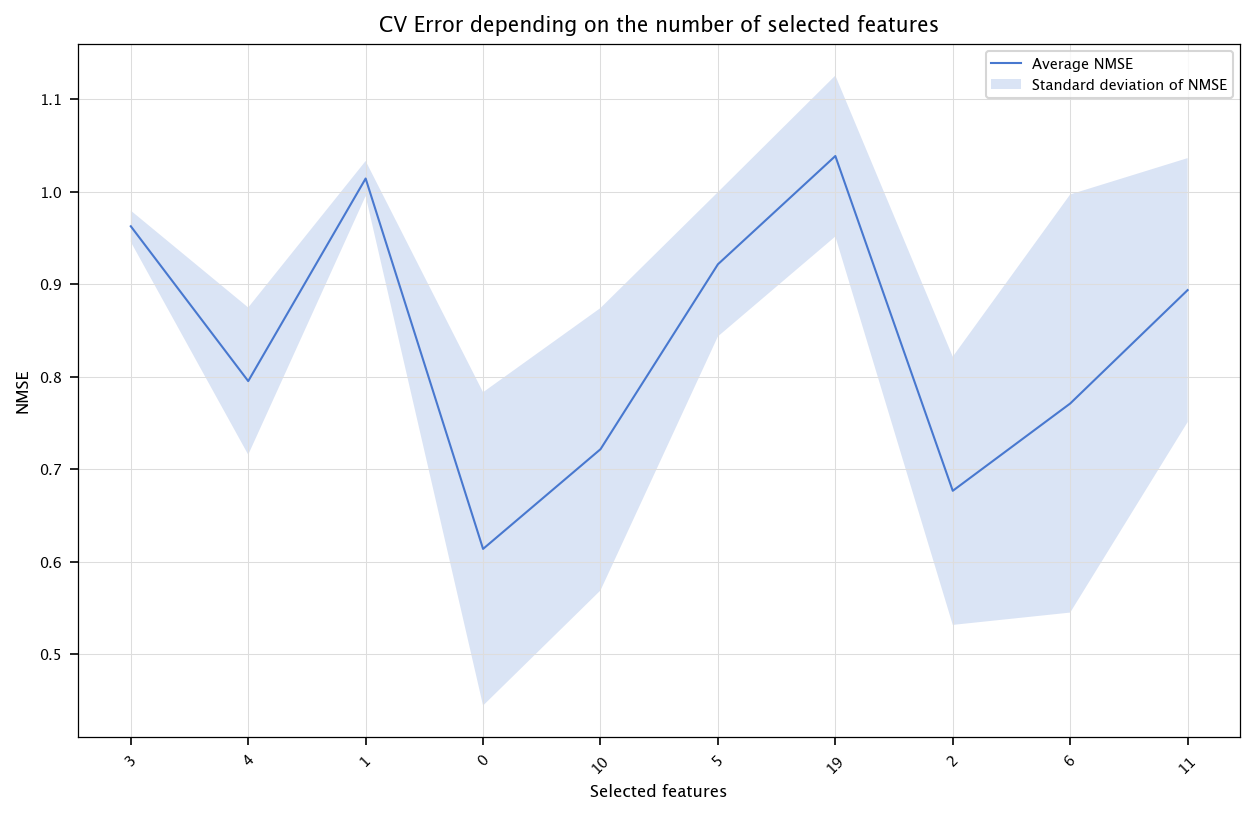

In [26]:
CV_err_nnet_single_model_fs = np.zeros((n_variables,10))
fold_id=0
for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
     # Rescale input to 0-1
    min_X, max_X = np.min(X_tr), np.max(X_tr)
    X_tr = (X_tr-min_X)/(max_X-min_X)
    X_ts = (X_ts-min_X)/(max_X-min_X)
    
    # Rescale output to 0-1
    min_Y, max_Y = np.min(Y_tr), np.max(Y_tr)
    Y_tr_rescale = (Y_tr-min_Y)/(max_Y-min_Y)
    
    mutual_info_values = compute_mi_vector(X_tr, Y_tr)
    selected = []
    candidates = list(range(n))
    
    for j in range(n_variables):
        redundancy_score = np.zeros(len(candidates))
        if len(selected)>0:
            for ci, cidx in enumerate(candidates):
                col_c = X_tr.iloc[:, cidx].values
                mis_c = []
                for sidx in selected:
                    col_s = X_tr.iloc[:, sidx].values
                    cc = np.corrcoef(col_s, col_c)[0,1]
                    if abs(cc)==1:
                        cc=0.999999
                    mis_c.append(-0.5*np.log(1-cc**2))
                redundancy_score[ci] = np.mean(mis_c)
        mRMR_score = mutual_info_values[candidates] - redundancy_score
        best_idx = candidates[np.argmax(mRMR_score)]
        selected.append(best_idx)
        candidates.remove(best_idx)
        
    for nb_features in range(1, n_variables+1):
        feats = [X.columns[i] for i in selected[:nb_features]]
        Y_tr_rescale = Y_tr/10.0
        model = MLPRegressor(hidden_layer_sizes=(20,), max_iter=1000000, learning_rate_init=0.005, random_state=3)
        model.fit(X_tr[feats], Y_tr_rescale)
        Y_hat_ts = model.predict(X_ts[feats])*10.0
        CV_err_nnet_single_model_fs[nb_features-1, fold_id] = nmse(Y_ts, Y_hat_ts)
    fold_id+=1

x = list(range(1, n_variables+1))
errors = np.array([np.mean(CV_err_nnet_single_model_fs[i, :]) for i in range(n_variables)])
stds = np.array([np.std(CV_err_nnet_single_model_fs[i, :]) for i in range(n_variables)])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, errors, label="Average NMSE")
ax.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Standard deviation of NMSE")
ax.set_title("CV Error depending on the number of selected features")
ax.set_xlabel("Selected features")
ax.set_ylabel("NMSE")
ax.set_xticks(ticks=x, labels=selected, rotation=45)
plt.legend()
plt.grid("on")
plt.show()

In [27]:
from sklearn.neighbors import KNeighborsRegressor

CV_err_lazy_single_model = []
for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    model = KNeighborsRegressor(n_neighbors=5)
    model.fit(X_tr, Y_tr)
    Y_hat_ts = model.predict(X_ts)
    CV_err_lazy_single_model.append(nmse(Y_ts, Y_hat_ts))

print(f"CV error: {np.mean(CV_err_lazy_single_model):.5f}, std dev: {np.std(CV_err_lazy_single_model):.5f}")

CV error: 0.64745, std dev: 0.08826


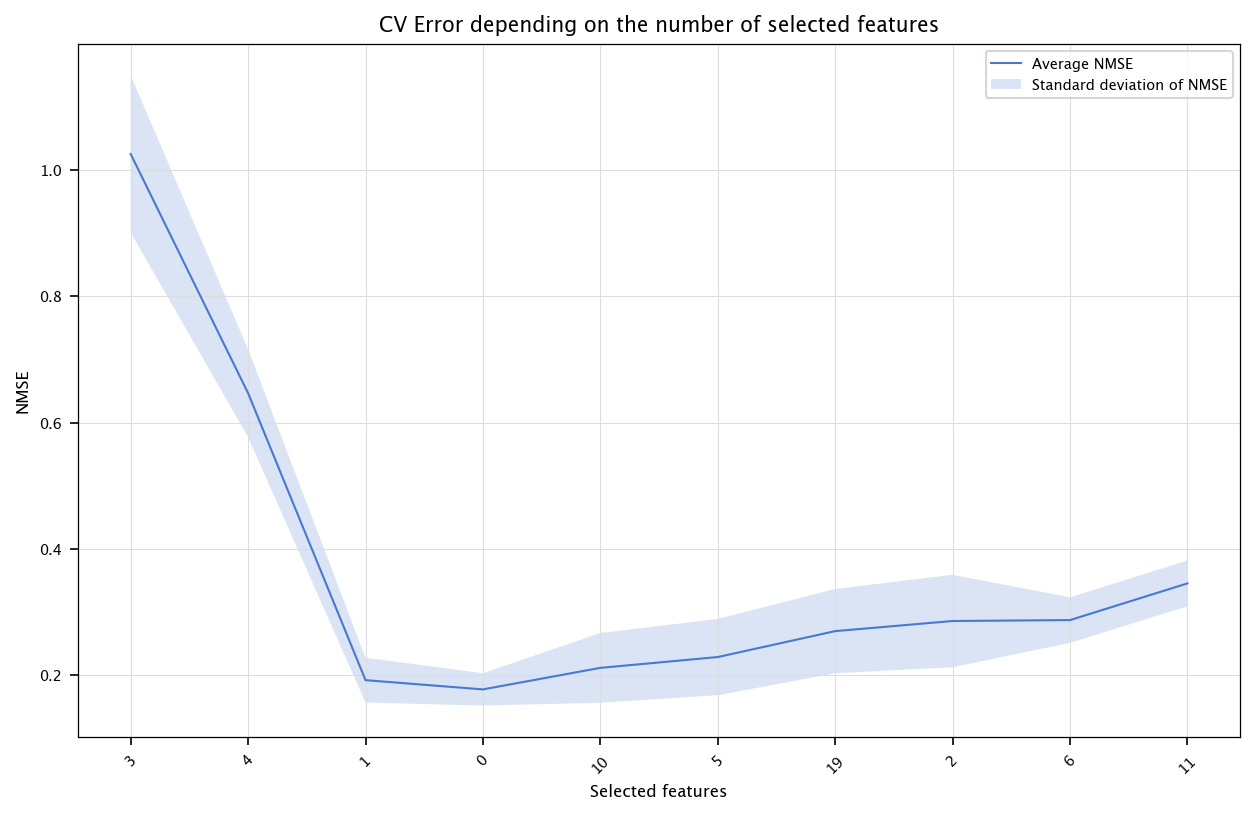

In [28]:
# Feature selection for KNN using mRMR
CV_err_lazy_single_model_fs = np.zeros((n_variables,10))
fold_id=0
for train_index, test_index in kf.split(X):
    X_tr, X_ts = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_ts = Y[train_index], Y[test_index]
    
    mutual_info_values = compute_mi_vector(X_tr, Y_tr)
    selected = []
    candidates = list(range(n))
    
    for j in range(n_variables):
        redundancy_score = np.zeros(len(candidates))
        if len(selected)>0:
            for ci, cidx in enumerate(candidates):
                col_c = X_tr.iloc[:, cidx].values
                mis_c = []
                for sidx in selected:
                    col_s = X_tr.iloc[:, sidx].values
                    cc = np.corrcoef(col_s, col_c)[0,1]
                    if abs(cc)==1:
                        cc=0.999999
                    mis_c.append(-0.5*np.log(1-cc**2))
                redundancy_score[ci] = np.mean(mis_c)
        mRMR_score = mutual_info_values[candidates] - redundancy_score
        best_idx = candidates[np.argmax(mRMR_score)]
        selected.append(best_idx)
        candidates.remove(best_idx)
        
    for nb_features in range(1, n_variables+1):
        feats = [X.columns[i] for i in selected[:nb_features]]
        model = KNeighborsRegressor(n_neighbors=5)
        model.fit(X_tr[feats], Y_tr)
        Y_hat_ts = model.predict(X_ts[feats])
        CV_err_lazy_single_model_fs[nb_features-1, fold_id] = nmse(Y_ts, Y_hat_ts)
    fold_id+=1

x = list(range(1, n_variables+1))
errors = np.array([np.mean(CV_err_lazy_single_model_fs[i, :]) for i in range(n_variables)])
stds = np.array([np.std(CV_err_lazy_single_model_fs[i, :]) for i in range(n_variables)])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, errors, label="Average NMSE")
ax.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Standard deviation of NMSE")
ax.set_title("CV Error depending on the number of selected features")
ax.set_xlabel("Selected features")
ax.set_ylabel("NMSE")
ax.set_xticks(ticks=x, labels=selected, rotation=45)
plt.legend()
plt.grid("on")
plt.show()